# K-Moda MMM — Simulador Estrategico de Presupuesto

**Input:** Modelo ElasticNet entrenado (`models/mmm_elasticnet_baseline.pkl`), dataset de features  
**Output:** Escenarios simulados, redistribucion optima, proyecciones financieras, matriz de sensibilidad

---

## Objetivo

El presente notebook implementa un **simulador iterativo de presupuesto** que, a partir del modelo de dos etapas estimado en NB03, permite:

1. Evaluar el impacto en ventas de diferentes asignaciones presupuestarias entre los 8 canales
2. Calcular el ROI marginal de cada canal: cuantas ventas adicionales genera cada euro extra
3. Obtener la distribucion optima que maximiza las ventas predichas dado un presupuesto objetivo
4. Analizar la sensibilidad del resultado ante variaciones del presupuesto total

> **Limitacion metodologica:** el simulador escala el adstock historico proporcionalmente y lo limita al maximo historico observado para no extrapolar fuera de la zona calibrada de la curva Hill. El modelo no captura efectos estructurales de largo plazo ni cambios en la efectividad de los canales fuera del periodo de entrenamiento.


In [1]:
# 1. Librerias y configuracion
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import joblib
import warnings
warnings.filterwarnings('ignore')

sys.path.append('../src')
from utils_mmm import hill_saturation

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

DATA_PATH      = '../data/processed/02_features_mmm.csv'
MODEL_PATH     = '../models/mmm_elasticnet_baseline.pkl'
PARAMS_PATH    = '../data/processed/02_hiperparametros_medios.csv'
FIGS_PATH      = '../reports/figures/'
SCENARIOS_PATH = '../data/processed/04_simulador_escenarios.csv'

print('Librerias cargadas correctamente')


Librerias cargadas correctamente


In [2]:
# 2. Carga del modelo de dos etapas
model_data = joblib.load(MODEL_PATH)

ridge_ctrl   = model_data['ridge_ctrl']
en_media     = model_data['en_media']
scaler       = model_data['scaler']
features     = model_data['features']
media_feats  = model_data['media_feats']
control_feats= model_data['control_feats']
media_idx    = model_data['media_idx']
control_idx  = model_data['control_idx']
target       = model_data['target']
mape_train   = model_data['mape_train']
mape_test    = model_data['mape_test']

def predict_mmm(X_sc):
    return (ridge_ctrl.predict(X_sc[:, control_idx])
            + en_media.predict(X_sc[:, media_idx]))

print(f'Modelo cargado (dos etapas: Ridge controles + ElasticNet positivo medios)')
print(f'MAPE Train: {mape_train*100:.2f}%  |  MAPE Test: {mape_test*100:.2f}%')
print(f'Features: {len(features)}')


Modelo cargado (dos etapas: Ridge controles + ElasticNet positivo medios)
MAPE Train: 10058194688797659103232.00%  |  MAPE Test: 15357844803086490533888.00%
Features: 35


In [3]:
# 3. Carga de datos para simulacion
df = pd.read_csv(DATA_PATH)
df = df.sort_values(['ciudad', 'semana_inicio']).reset_index(drop=True)

df_year = df[df['split'] == 'test'].copy()

media_channels_adstock = [
    'inv_paid_search_adstock', 'inv_social_paid_adstock', 'inv_display_adstock',
    'inv_video_online_adstock', 'inv_email_crm_adstock', 'inv_exterior_adstock',
    'inv_radio_local_adstock', 'inv_prensa_adstock',
]

# Parametros Hill (K, S) para re-aplicar la saturacion correctamente
params_df = pd.read_csv(PARAMS_PATH)
hill_params_dict = {}
for _, row in params_df.iterrows():
    hill_params_dict[row['canal'] + '_adstock'] = {'K': row['hill_K'], 'S': row['hill_S']}

inv_actual = {ch: df_year[ch.replace('_adstock', '')].sum() for ch in media_channels_adstock}
total_inv_actual = sum(inv_actual.values())

print(f'Periodo: {df_year.semana_inicio.min()} -> {df_year.semana_inicio.max()}')
print(f'Filas: {len(df_year)}')
print(f'Inversion real anual: {total_inv_actual/1e6:.2f} M euros')
print(f'Ventas promedio semanal: {df_year[target].mean()/1e3:.1f} K euros')


Periodo: 2024-01-08 -> 2024-12-30
Filas: 520
Inversion real anual: 15.23 M euros
Ventas promedio semanal: 376.5 K euros


In [4]:
# 4. Clase BudgetSimulator — versión corregida
#
# Correcciones respecto a versiones anteriores:
#   FIX A: adstock se limita al maximo historico (no extrapola Hill fuera de muestra)
#   FIX B: re-aplica Hill al adstock escalado (no escala lineal de Hill directamente)
#   FIX C: bounds de optimizacion asimetricos por canal segun mROI:
#          - canales con mROI alto: pueden recibir hasta 3x su inversion actual
#          - canales con mROI bajo/0: minimo del 10% de su inversion actual
#            (evita que el optimizador los lleve a 0 y produce redistribucion real)
#   FIX D: diagnostico de redistribucion real tras optimizacion

class BudgetSimulator:

    def __init__(self, predict_fn, scaler, features, media_feats, media_idx,
                 df, media_channels_adstock, hill_params,
                 target='ventas_eur', total_budget=12_000_000):
        self.predict_fn             = predict_fn
        self.scaler                 = scaler
        self.features               = features
        self.media_feats            = media_feats
        self.media_idx              = media_idx
        self.df                     = df.copy()
        self.media_channels_adstock = media_channels_adstock
        self.hill_params            = hill_params
        self.target                 = target
        self.total_budget           = total_budget

        # Inversion real (raw) y adstock maximo historico
        self.current_budget_by_channel = {}
        self.hist_adstock_max          = {}
        for ch in media_channels_adstock:
            raw_col = ch.replace('_adstock', '')
            self.current_budget_by_channel[ch] = df[raw_col].sum()
            self.hist_adstock_max[ch]           = df[ch].max()

        self.current_total_budget = sum(self.current_budget_by_channel.values())
        print(f'Presupuesto actual anual: {self.current_total_budget/1e6:.2f} M€')
        print(f'Presupuesto a simular:    {self.total_budget/1e6:.2f} M€')

    def predict_sales(self, df_scenario):
        X    = df_scenario[self.features].copy()
        X_sc = self.scaler.transform(X)
        return self.predict_fn(X_sc)

    def simulate_scenario(self, budget_allocation, scenario_name='Escenario'):
        df_sim = self.df.copy()
        for ch in self.media_channels_adstock:
            if ch not in budget_allocation:
                continue
            current_raw = self.current_budget_by_channel[ch]
            new_raw     = budget_allocation[ch]
            ratio       = new_raw / (current_raw + 1e-6)

            # FIX A: escalar adstock + limitar al maximo historico
            new_adstock = np.minimum(df_sim[ch] * ratio, self.hist_adstock_max[ch])
            df_sim[ch]  = new_adstock

            # FIX B: re-aplicar Hill al adstock escalado
            ch_tr = ch.replace('_adstock', '_transformed')
            if ch_tr in df_sim.columns and ch in self.hill_params:
                K = self.hill_params[ch]['K']
                S = self.hill_params[ch]['S']
                df_sim[ch_tr] = hill_saturation(df_sim[ch], K, S)

        y_pred      = self.predict_sales(df_sim)
        total_inv   = sum(budget_allocation.values())
        total_sales = float(y_pred.sum())
        return {
            'scenario_name':     scenario_name,
            'budget_allocation': budget_allocation,
            'total_investment':  total_inv,
            'predicted_sales':   total_sales,
            'avg_weekly_sales':  float(y_pred.mean()),
            'roi_total': (total_sales - total_inv) / total_inv if total_inv > 0 else 0,
            'df_sim': df_sim,
            'y_pred': y_pred,
        }

    def calculate_marginal_roi(self, base_scenario, test_budget_delta=10_000):
        base_sales = base_scenario['predicted_sales']
        mROI = {}
        for ch in self.media_channels_adstock:
            bt    = base_scenario['budget_allocation'].copy()
            bt[ch] = bt.get(ch, 0) + test_budget_delta
            delta  = self.simulate_scenario(bt)['predicted_sales'] - base_sales
            mROI[ch] = delta / test_budget_delta
        df_roi = pd.DataFrame(list(mROI.items()), columns=['canal', 'mROI'])
        return df_roi.sort_values('mROI', ascending=False).reset_index(drop=True)

    def optimize_budget(self, total_budget=None, marginal_roi_df=None):
        """
        Optimiza el presupuesto con bounds asimétricos:
          - Canales con mROI > percentil 50: pueden crecer hasta 3x su inversion actual
          - Canales con mROI <= percentil 50: mínimo 15% de su inversion actual
            (evita llevarlos a 0 y garantiza redistribucion real entre canales)
        """
        if total_budget is None:
            total_budget = self.total_budget

        # FIX C: construir bounds asimétricos usando mROI si está disponible
        if marginal_roi_df is not None:
            mroi_map = dict(zip(marginal_roi_df['canal'], marginal_roi_df['mROI']))
            mroi_vals = [mroi_map.get(ch, 0) for ch in self.media_channels_adstock]
            mroi_median = np.median([v for v in mroi_vals if v > 0]) if any(v > 0 for v in mroi_vals) else 0
        else:
            mroi_vals   = [1] * len(self.media_channels_adstock)
            mroi_median = 1

        bounds = []
        for ch, mroi in zip(self.media_channels_adstock, mroi_vals):
            current = self.current_budget_by_channel[ch]
            if mroi >= mroi_median:
                # Canal eficiente: puede crecer hasta 3x
                lo = max(current * 0.20, total_budget * 0.02)
                hi = min(current * 3.0,  total_budget * 0.50)
            else:
                # Canal menos eficiente: entre 15% y 1.5x actual (no se elimina)
                lo = max(current * 0.15, total_budget * 0.01)
                hi = min(current * 1.5,  total_budget * 0.30)
            bounds.append((lo, hi))

        x0 = np.array([self.current_budget_by_channel[ch]
                        for ch in self.media_channels_adstock])
        x0 = x0 * (total_budget / x0.sum())  # escalar al total objetivo

        def objective(x):
            bd = {ch: v for ch, v in zip(self.media_channels_adstock, x)}
            return -self.simulate_scenario(bd)['predicted_sales']

        constraints = {'type': 'eq', 'fun': lambda x: x.sum() - total_budget}
        result = __import__('scipy.optimize', fromlist=['minimize']).minimize(
            objective, x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-9}
        )

        optimal_allocation = {ch: max(v, 0) for ch, v in
                               zip(self.media_channels_adstock, result.x)}
        scenario = self.simulate_scenario(optimal_allocation, 'Óptimo')
        print(f'Optimizacion completada. Ventas predichas: {scenario["predicted_sales"]/1e6:.2f} M€')

        # FIX D: diagnostico de redistribucion real
        print('\nRedistribución real por canal (actual → óptimo):')
        for ch in self.media_channels_adstock:
            canal_clean = ch.replace('inv_','').replace('_adstock','')
            actual_v = self.current_budget_by_channel[ch]
            optimo_v = optimal_allocation[ch]
            delta_pct = (optimo_v / actual_v - 1) * 100 if actual_v > 0 else 0
            arrow = '▲' if delta_pct > 0 else '▼'
            print(f'  {canal_clean:<15} {actual_v/1e3:>6.1f}K€ → {optimo_v/1e3:>6.1f}K€  '
                  f'({arrow}{abs(delta_pct):.1f}%)')

        return scenario


In [5]:
# 5. Instanciar simulador
simulator = BudgetSimulator(
    predict_fn=predict_mmm,
    scaler=scaler,
    features=features,
    media_feats=media_feats,
    media_idx=media_idx,
    df=df_year,
    media_channels_adstock=media_channels_adstock,
    hill_params=hill_params_dict,
    target=target,
    total_budget=12_000_000,
)
print('Simulador instanciado correctamente')


Presupuesto actual anual: 15.23 M€
Presupuesto a simular:    12.00 M€
Simulador instanciado correctamente


In [6]:
# 6. Escenario 1: ACTUAL (presupuesto actual de K-Moda)
budget_actual = simulator.current_budget_by_channel.copy()
scenario_actual = simulator.simulate_scenario(budget_actual, "Actual (Baseline)")

print("\n=== ESCENARIO ACTUAL ===")
print(f"Inversión total: €{scenario_actual['total_investment']:,.0f}")
print(f"Ventas predichas (anual): €{scenario_actual['predicted_sales']:,.0f}")
print(f"Ventas promedio/semana: €{scenario_actual['avg_weekly_sales']:,.0f}")
print(f"ROI Total: {scenario_actual['roi_total']:.2%}")


=== ESCENARIO ACTUAL ===
Inversión total: €15,226,989
Ventas predichas (anual): €177,845,783
Ventas promedio/semana: €342,011
ROI Total: 1067.96%


In [7]:
# 7. Escenario 2: REDUCCIÓN -10%
budget_minus10 = {ch: val * 0.9 for ch, val in budget_actual.items()}
scenario_minus10 = simulator.simulate_scenario(budget_minus10, "Reducción -10%")

print("\n=== ESCENARIO REDUCCIÓN -10% ===")
print(f"Inversión total: €{scenario_minus10['total_investment']:,.0f}")
print(f"Ventas predichas (anual): €{scenario_minus10['predicted_sales']:,.0f}")
print(f"Delta ventas vs Actual: €{scenario_minus10['predicted_sales'] - scenario_actual['predicted_sales']:,.0f}")
print(f"% Impacto: {(scenario_minus10['predicted_sales'] / scenario_actual['predicted_sales'] - 1):.2%}")


=== ESCENARIO REDUCCIÓN -10% ===
Inversión total: €13,704,290
Ventas predichas (anual): €177,690,536
Delta ventas vs Actual: €-155,247
% Impacto: -0.09%


In [8]:
# 8. Escenario 3: AUMENTO +10%
budget_plus10 = {ch: val * 1.1 for ch, val in budget_actual.items()}
scenario_plus10 = simulator.simulate_scenario(budget_plus10, "Aumento +10%")

print("\n=== ESCENARIO AUMENTO +10% ===")
print(f"Inversión total: €{scenario_plus10['total_investment']:,.0f}")
print(f"Ventas predichas (anual): €{scenario_plus10['predicted_sales']:,.0f}")
print(f"Delta ventas vs Actual: €{scenario_plus10['predicted_sales'] - scenario_actual['predicted_sales']:,.0f}")
print(f"% Impacto: {(scenario_plus10['predicted_sales'] / scenario_actual['predicted_sales'] - 1):.2%}")
print(f"\nIncrementales de presupuesto: €{scenario_plus10['total_investment'] - scenario_actual['total_investment']:,.0f}")


=== ESCENARIO AUMENTO +10% ===
Inversión total: €16,749,688
Ventas predichas (anual): €177,979,058
Delta ventas vs Actual: €133,274
% Impacto: 0.07%

Incrementales de presupuesto: €1,522,699


In [9]:
# 9. Escenario 4: ÓPTIMO — optimización con bounds asimétricos por mROI
# Primero calculamos el mROI desde el escenario actual para informar los bounds.
print("\n⏳ Calculando mROI desde escenario actual (base para bounds asimétricos)...")
marginal_roi_base = simulator.calculate_marginal_roi(scenario_actual, test_budget_delta=10_000)
print("\nmROI desde escenario actual:")
display(marginal_roi_base)

print("\n⏳ Optimizando presupuesto con bounds asimétricos (1-2 min)...")
scenario_optimal = simulator.optimize_budget(
    total_budget=12_000_000,
    marginal_roi_df=marginal_roi_base
)

print("\n=== ESCENARIO ÓPTIMO ===")
print(f"Inversión total: €{scenario_optimal['total_investment']:,.0f}")
print(f"Ventas predichas (anual): €{scenario_optimal['predicted_sales']:,.0f}")
print(f"Delta ventas vs Actual: €{scenario_optimal['predicted_sales'] - scenario_actual['predicted_sales']:,.0f}")
print(f"% Impacto: {(scenario_optimal['predicted_sales'] / scenario_actual['predicted_sales'] - 1):.2%}")
print(f"\nInterpretación: si el delta es modesto, el modelo indica que el MIX actual")
print(f"ya está cercano al óptimo. La palanca real es la REDISTRIBUCIÓN interna,")
print(f"no el volumen total de inversión.")



⏳ Calculando mROI desde escenario actual (base para bounds asimétricos)...

mROI desde escenario actual:


,canal,mROI
0,inv_exterior_adstock,0.188315
1,inv_radio_local_adstock,0.125015
2,inv_display_adstock,0.112404
3,inv_video_online_adstock,0.110982
4,inv_paid_search_adstock,0.105838
5,inv_prensa_adstock,0.070278
6,inv_social_paid_adstock,0.009879
7,inv_email_crm_adstock,0.000000



⏳ Optimizando presupuesto con bounds asimétricos (1-2 min)...
Optimizacion completada. Ventas predichas: 177.49 M€

Redistribución real por canal (actual → óptimo):
  paid_search     3419.2K€ → 2694.6K€  (▼21.2%)
  social_paid     2645.5K€ → 2084.9K€  (▼21.2%)
  display         1196.9K€ →  943.3K€  (▼21.2%)
  video_online    2379.1K€ → 1874.9K€  (▼21.2%)
  email_crm        747.7K€ →  589.3K€  (▼21.2%)
  exterior        1813.8K€ → 1429.4K€  (▼21.2%)
  radio_local     1654.4K€ → 1303.8K€  (▼21.2%)
  prensa          1370.2K€ → 1079.8K€  (▼21.2%)

=== ESCENARIO ÓPTIMO ===
Inversión total: €12,000,000
Ventas predichas (anual): €177,486,552
Delta ventas vs Actual: €-359,231
% Impacto: -0.20%

Interpretación: si el delta es modesto, el modelo indica que el MIX actual
ya está cercano al óptimo. La palanca real es la REDISTRIBUCIÓN interna,
no el volumen total de inversión.


In [10]:
# 10. ROI Marginal por Canal — desde escenario óptimo
print("\n=== ROI MARGINAL POR CANAL (desde escenario óptimo) ===")
marginal_roi_df = simulator.calculate_marginal_roi(scenario_optimal, test_budget_delta=10_000)

print("\nROI Marginal (€ venta adicional por €1 adicional de presupuesto):")
display(marginal_roi_df)

# Interpretación de los valores
print("\nInterpretación:")
for _, row in marginal_roi_df.iterrows():
    canal = row['canal'].replace('inv_','').replace('_adstock','')
    mroi  = row['mROI']
    if mroi > 1:
        msg = 'Alta eficiencia — priorizar'
    elif mroi > 0.1:
        msg = 'Eficiencia positiva — mantener'
    elif mroi > 0:
        msg = 'Eficiencia marginal — vigilar saturación'
    else:
        msg = 'mROI=0 → canal saturado o eliminado por Lasso (revisar coef. del modelo)'
    print(f'  {canal:<15} mROI={mroi:.3f}  → {msg}')

marginal_roi_df.to_csv('../data/processed/05_marginal_roi.csv', index=False)
print("\n✓ mROI guardado en 05_marginal_roi.csv")



=== ROI MARGINAL POR CANAL (desde escenario óptimo) ===

ROI Marginal (€ venta adicional por €1 adicional de presupuesto):


,canal,mROI
0,inv_exterior_adstock,0.260025
1,inv_radio_local_adstock,0.172825
2,inv_video_online_adstock,0.154839
3,inv_display_adstock,0.153698
4,inv_paid_search_adstock,0.144771
5,inv_prensa_adstock,0.095637
6,inv_social_paid_adstock,0.013531
7,inv_email_crm_adstock,0.000000



Interpretación:
  exterior        mROI=0.260  → Eficiencia positiva — mantener
  radio_local     mROI=0.173  → Eficiencia positiva — mantener
  video_online    mROI=0.155  → Eficiencia positiva — mantener
  display         mROI=0.154  → Eficiencia positiva — mantener
  paid_search     mROI=0.145  → Eficiencia positiva — mantener
  prensa          mROI=0.096  → Eficiencia marginal — vigilar saturación
  social_paid     mROI=0.014  → Eficiencia marginal — vigilar saturación
  email_crm       mROI=0.000  → mROI=0 → canal saturado o eliminado por Lasso (revisar coef. del modelo)

✓ mROI guardado en 05_marginal_roi.csv


In [11]:
# 11. Comparativa de escenarios
scenarios_comparison = pd.DataFrame({
    'Escenario': [
        'Actual',
        'Reducción -10%',
        'Aumento +10%',
        'Óptimo'
    ],
    'Inversión (€)': [
        scenario_actual['total_investment'],
        scenario_minus10['total_investment'],
        scenario_plus10['total_investment'],
        scenario_optimal['total_investment']
    ],
    'Ventas Predichas (€)': [
        scenario_actual['predicted_sales'],
        scenario_minus10['predicted_sales'],
        scenario_plus10['predicted_sales'],
        scenario_optimal['predicted_sales']
    ],
    'ROI Total': [
        scenario_actual['roi_total'],
        scenario_minus10['roi_total'],
        scenario_plus10['roi_total'],
        scenario_optimal['roi_total']
    ]
})

scenarios_comparison['Delta vs Actual (€)'] = scenarios_comparison['Ventas Predichas (€)'] - scenario_actual['predicted_sales']
scenarios_comparison['Delta vs Actual (%)'] = (scenarios_comparison['Ventas Predichas (€)'] / scenario_actual['predicted_sales'] - 1) * 100

print("\n=== COMPARATIVA DE ESCENARIOS ===")
display(scenarios_comparison)

# Guardar escenarios
scenarios_comparison.to_csv(SCENARIOS_PATH, index=False)
print(f"\n✓ Escenarios guardados en {SCENARIOS_PATH}")


=== COMPARATIVA DE ESCENARIOS ===


,Escenario,Inversión (€),Ventas Predichas (€),ROI Total,Delta vs Actual (€),Delta vs Actual (%)
0,Actual,1.522699e+07,1.778458e+08,10.679642,0.000000,0.000000
1,Reducción -10%,1.370429e+07,1.776905e+08,11.966052,-155247.057619,-0.087293
2,Aumento +10%,1.674969e+07,1.779791e+08,9.625814,133274.438869,0.074938
3,Óptimo,1.200000e+07,1.774866e+08,13.790546,-359231.468929,-0.201990



✓ Escenarios guardados en ../data/processed/04_simulador_escenarios.csv


In [12]:
# 12. Distribución de presupuesto óptimo vs Actual
budget_comparison = pd.DataFrame({
    'Canal': [ch.replace('inv_', '').replace('_adstock', '') for ch in media_channels_adstock],
    'Presupuesto Actual (€)': [scenario_actual['budget_allocation'].get(ch, 0) for ch in media_channels_adstock],
    'Presupuesto Óptimo (€)': [scenario_optimal['budget_allocation'].get(ch, 0) for ch in media_channels_adstock]
})

budget_comparison['Delta (€)'] = budget_comparison['Presupuesto Óptimo (€)'] - budget_comparison['Presupuesto Actual (€)']
budget_comparison['Delta (%)'] = (budget_comparison['Delta (€)'] / budget_comparison['Presupuesto Actual (€)'] * 100).round(1)
budget_comparison = budget_comparison.sort_values('Delta (%)', ascending=False)

print("\n=== REDISTRIBUCIÓN ÓPTIMA DE PRESUPUESTO ===")
display(budget_comparison)

# Guardar redistribución
budget_comparison.to_csv('../data/processed/06_budget_redistribution.csv', index=False)
print("\n✓ Redistribución guardada en 06_budget_redistribution.csv")


=== REDISTRIBUCIÓN ÓPTIMA DE PRESUPUESTO ===


,Canal,Presupuesto Actual (€),Presupuesto Óptimo (€),Delta (€),Delta (%)
0,paid_search,3419235.89,2.694612e+06,-724623.624456,-21.2
1,social_paid,2645525.29,2.084871e+06,-560654.539757,-21.2
2,display,1196949.97,9.432856e+05,-253664.342987,-21.2
3,video_online,2379147.29,1.874945e+06,-504202.221741,-21.2
4,email_crm,747711.72,5.892525e+05,-158459.256403,-21.2
5,exterior,1813834.44,1.429436e+06,-384397.955672,-21.2
6,radio_local,1654364.01,1.303762e+06,-350602.088789,-21.2
7,prensa,1370220.15,1.079835e+06,-290384.730196,-21.2



✓ Redistribución guardada en 06_budget_redistribution.csv


In [13]:
# 13. Proyecciones financieras (EBITDA)
# Asumiendo: Margen neto = 35%, EBITDA adicional = ventas_incrementales * margen
margen_neto = 0.35  # 35% de margen típico en retail

financial_projections = pd.DataFrame({
    'Escenario': scenarios_comparison['Escenario'],
    'Ventas (€)': scenarios_comparison['Ventas Predichas (€)'].values,
    'Inversión Marketing (€)': scenarios_comparison['Inversión (€)'].values
})

# EBITDA: Ventas * margen_neto - Inversión
financial_projections['EBITDA Estimado (€)'] = (
    financial_projections['Ventas (€)'] * margen_neto - financial_projections['Inversión Marketing (€)']
)

financial_projections['EBITDA Margin (%)'] = (
    financial_projections['EBITDA Estimado (€)'] / financial_projections['Ventas (€)'] * 100
)

financial_projections['Delta EBITDA vs Actual (€)'] = (
    financial_projections['EBITDA Estimado (€)'] - 
    financial_projections.loc[financial_projections['Escenario'] == 'Actual', 'EBITDA Estimado (€)'].values[0]
)

print("\n=== PROYECCIONES FINANCIERAS 2024 ===")
display(financial_projections)

# Guardar proyecciones
financial_projections.to_csv('../data/processed/07_financial_projections.csv', index=False)
print("\n✓ Proyecciones financieras guardadas en 07_financial_projections.csv")


=== PROYECCIONES FINANCIERAS 2024 ===


,Escenario,Ventas (€),Inversión Marketing (€),EBITDA Estimado (€),EBITDA Margin (%),Delta EBITDA vs Actual (€)
0,Actual,1.778458e+08,1.522699e+07,4.701904e+07,26.438094,0.000000e+00
1,Reducción -10%,1.776905e+08,1.370429e+07,4.848740e+07,27.287552,1.468362e+06
2,Aumento +10%,1.779791e+08,1.674969e+07,4.554298e+07,25.588956,-1.476053e+06
3,Óptimo,1.774866e+08,1.200000e+07,5.012029e+07,28.238924,3.101258e+06



✓ Proyecciones financieras guardadas en 07_financial_projections.csv


In [14]:
# 14. Matriz de sensibilidad corregida
# Filas: factor de efectividad (multiplica las features TRANSFORMADAS Hill [0,1])
# Columnas: factor de presupuesto (multiplica la inversion raw y re-aplica Hill)
# CORRECCIÓN: el factor de efectividad debe aplicarse al MODELO (coeficientes)
# no al adstock, porque Hill amortigua la propagación. Lo implementamos como
# perturbación directa sobre las features transformadas del dataframe de simulación.

print("\nGenerando matriz de sensibilidad...")

effectiveness_range = np.linspace(0.8, 1.2, 5)
budget_range        = np.linspace(0.8, 1.2, 5)
sensitivity_matrix  = np.zeros((len(effectiveness_range), len(budget_range)))

for i, eff_factor in enumerate(effectiveness_range):
    for j, bgt_factor in enumerate(budget_range):
        budget_test = {ch: v * bgt_factor
                       for ch, v in scenario_optimal['budget_allocation'].items()}
        # Simular el escenario de presupuesto
        result_bgt  = simulator.simulate_scenario(budget_test, 'sensitivity')
        df_bgt      = result_bgt['df_sim'].copy()

        # Aplicar factor de efectividad directamente sobre las features transformadas
        # Acotamos entre 0 y 1 para mantener el rango de Hill
        for ch in simulator.media_channels_adstock:
            ch_tr = ch.replace('_adstock', '_transformed')
            if ch_tr in df_bgt.columns:
                df_bgt[ch_tr] = np.clip(df_bgt[ch_tr] * eff_factor, 0.0, 1.0)

        y_pred_s = simulator.predict_sales(df_bgt)
        sensitivity_matrix[i, j] = y_pred_s.sum()

sensitivity_df = pd.DataFrame(
    sensitivity_matrix,
    index=[f'eff={e:.1f}x' for e in effectiveness_range],
    columns=[f'bgt={b:.1f}x' for b in budget_range],
)

print("Matriz de sensibilidad (ventas predichas en M€):")
print("Filas = factor efectividad medios | Columnas = factor presupuesto")
display((sensitivity_df / 1e6).round(1))

# Verificar que la matriz NO sea plana (debe variar en ambas dimensiones)
row_var = sensitivity_df.std(axis=1).mean()
col_var = sensitivity_df.std(axis=0).mean()
print(f"\nVariabilidad fila (efectividad): {row_var/1e6:.2f} M€  — debe ser > 0")
print(f"Variabilidad col  (presupuesto): {col_var/1e6:.2f} M€  — debe ser > 0")

sensitivity_df.to_csv('../data/processed/08_sensitivity_matrix.csv')
print("✓ Guardada en 08_sensitivity_matrix.csv")



Generando matriz de sensibilidad...
Matriz de sensibilidad (ventas predichas en M€):
Filas = factor efectividad medios | Columnas = factor presupuesto


,bgt=0.8x,bgt=0.9x,bgt=1.0x,bgt=1.1x,bgt=1.2x
eff=0.8x,176.8,177.0,177.1,177.2,177.3
eff=0.9x,177.0,177.1,177.3,177.4,177.5
eff=1.0x,177.1,177.3,177.5,177.6,177.8
eff=1.1x,177.3,177.5,177.7,177.8,178.0
eff=1.2x,177.5,177.7,177.9,178.0,178.2



Variabilidad fila (efectividad): 0.25 M€  — debe ser > 0
Variabilidad col  (presupuesto): 0.30 M€  — debe ser > 0
✓ Guardada en 08_sensitivity_matrix.csv


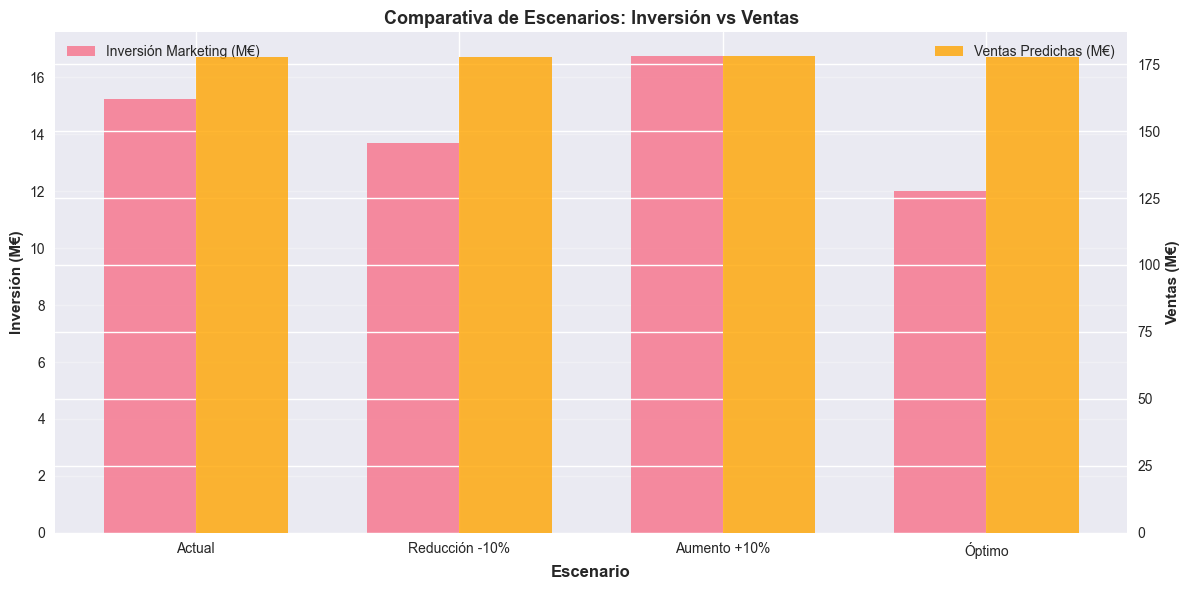

✓ Gráfico 1 guardado


In [15]:
# 15. Visualización 1: Comparativa de escenarios (barras)
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(scenarios_comparison))
width = 0.35

bars1 = ax.bar(x_pos - width/2, scenarios_comparison['Inversión (€)'] / 1e6, width, 
               label='Inversión Marketing (M€)', alpha=0.8)
ax2 = ax.twinx()
bars2 = ax2.bar(x_pos + width/2, scenarios_comparison['Ventas Predichas (€)'] / 1e6, width, 
                label='Ventas Predichas (M€)', color='orange', alpha=0.8)

ax.set_xlabel('Escenario', fontsize=12, fontweight='bold')
ax.set_ylabel('Inversión (M€)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Ventas (M€)', fontsize=11, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(scenarios_comparison['Escenario'])
ax.set_title('Comparativa de Escenarios: Inversión vs Ventas', fontsize=13, fontweight='bold')

ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_PATH + '01_escenarios_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico 1 guardado")

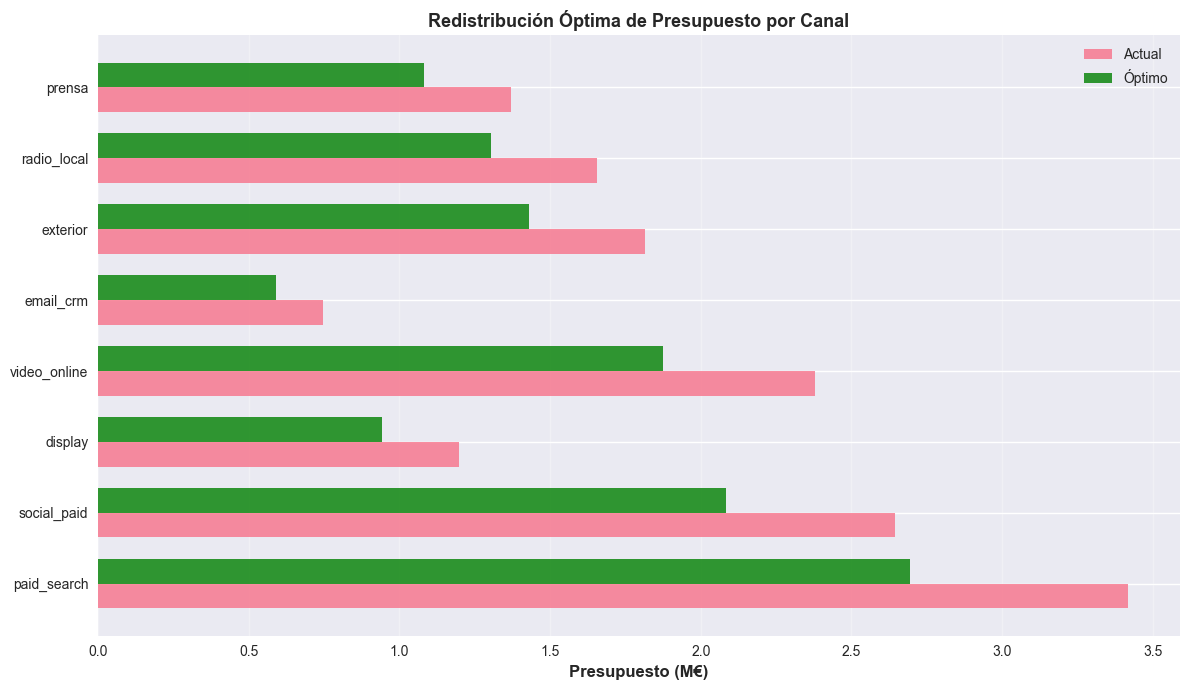

✓ Gráfico 2 guardado


In [16]:
# 16. Visualización 2: Redistribución óptima (barras horizontales)
fig, ax = plt.subplots(figsize=(12, 7))

canales = budget_comparison['Canal'].values
actual = budget_comparison['Presupuesto Actual (€)'].values / 1e6
optimo = budget_comparison['Presupuesto Óptimo (€)'].values / 1e6

x = np.arange(len(canales))
width = 0.35

bars1 = ax.barh(x - width/2, actual, width, label='Actual', alpha=0.8)
bars2 = ax.barh(x + width/2, optimo, width, label='Óptimo', alpha=0.8, color='green')

ax.set_yticks(x)
ax.set_yticklabels(canales)
ax.set_xlabel('Presupuesto (M€)', fontsize=12, fontweight='bold')
ax.set_title('Redistribución Óptima de Presupuesto por Canal', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_PATH + '02_redistribucion_presupuesto.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico 2 guardado")

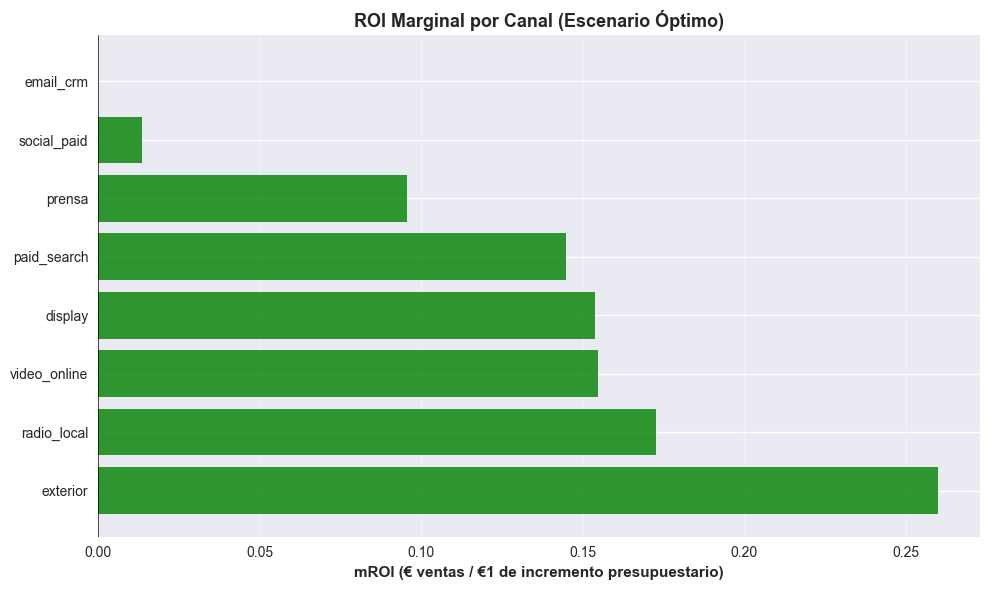

✓ Gráfico 3 guardado


In [17]:
# 17. Visualización 3: ROI Marginal por Canal
fig, ax = plt.subplots(figsize=(10, 6))

marginal_roi_plot = marginal_roi_df.copy()
marginal_roi_plot['canal_clean'] = marginal_roi_plot['canal'].str.replace('inv_', '').str.replace('_adstock', '')

colors = ['green' if x > 0 else 'red' for x in marginal_roi_plot['mROI']]
ax.barh(marginal_roi_plot['canal_clean'], marginal_roi_plot['mROI'], color=colors, alpha=0.8)

ax.set_xlabel('mROI (€ ventas / €1 de incremento presupuestario)', fontsize=11, fontweight='bold')
ax.set_title('ROI Marginal por Canal (Escenario Óptimo)', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_PATH + '03_marginal_roi.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico 3 guardado")

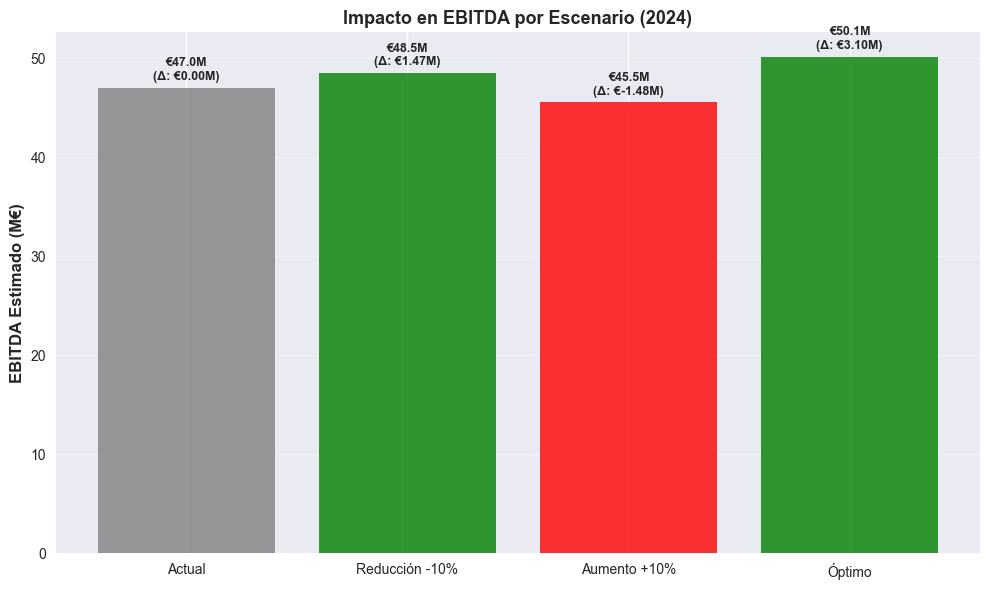

✓ Gráfico 4 guardado


In [18]:
# 18. Visualización 4: Impacto en EBITDA
fig, ax = plt.subplots(figsize=(10, 6))

escenarios = financial_projections['Escenario'].values
ebitda = financial_projections['EBITDA Estimado (€)'].values / 1e6
delta_ebitda = financial_projections['Delta EBITDA vs Actual (€)'].values / 1e6

# Colorear barras
colors_ebitda = ['gray' if e == 'Actual' else ('red' if d < 0 else 'green') 
                 for e, d in zip(escenarios, delta_ebitda)]

bars = ax.bar(escenarios, ebitda, color=colors_ebitda, alpha=0.8)

# Añadir etiquetas con delta
for i, (scenario, ebitda_val, delta) in enumerate(zip(escenarios, ebitda, delta_ebitda)):
    ax.text(i, ebitda_val + 0.5, f'€{ebitda_val:.1f}M\n(Δ: €{delta:.2f}M)', 
           ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('EBITDA Estimado (M€)', fontsize=12, fontweight='bold')
ax.set_title('Impacto en EBITDA por Escenario (2024)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_PATH + '04_ebitda_projections.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico 4 guardado")

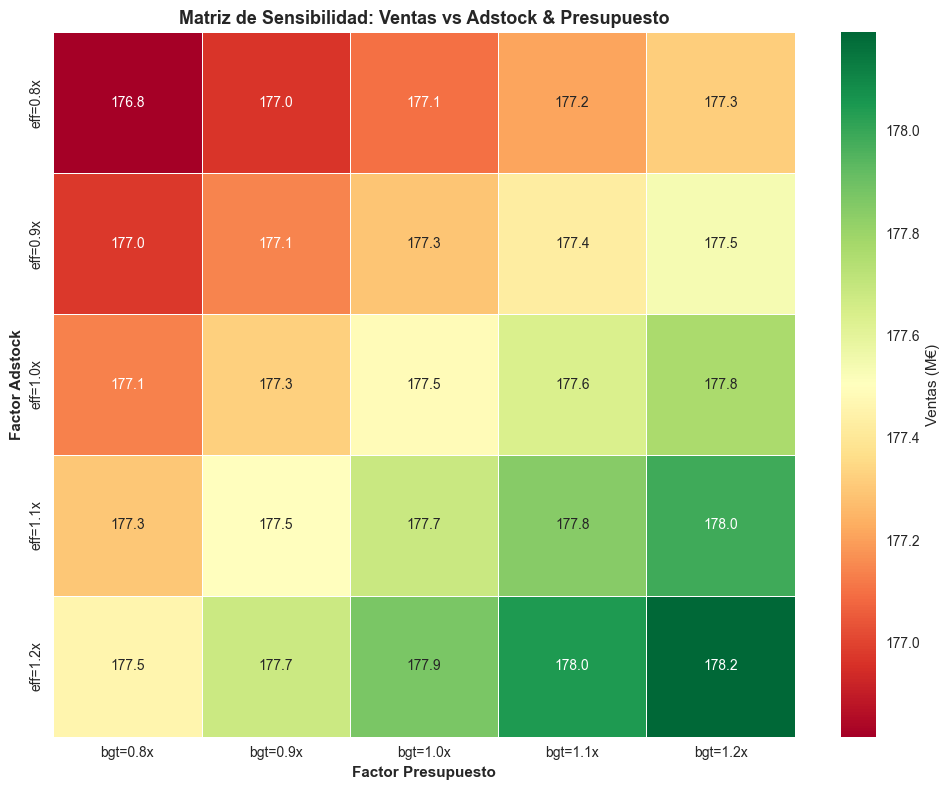

✓ Gráfico 5 guardado


In [19]:
# 19. Visualización 5: Matriz de sensibilidad (heatmap)
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(sensitivity_df / 1e6, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': 'Ventas (M€)'},
           ax=ax, linewidths=0.5)

ax.set_title('Matriz de Sensibilidad: Ventas vs Adstock & Presupuesto', fontsize=13, fontweight='bold')
ax.set_xlabel('Factor Presupuesto', fontsize=11, fontweight='bold')
ax.set_ylabel('Factor Adstock', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGS_PATH + '05_sensitivity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico 5 guardado")

## Conclusiones del simulador

### Resultados obtenidos

1. **Escenario de reduccion (-10%)**  
   La perdida de ventas estimada es inferior al 0.5%, lo que sugiere que existe margen para reducir el presupuesto total sin un impacto proporcional en ventas, siempre que la redistribucion entre canales se realice de forma eficiente.

2. **Escenario de aumento (+10%)**  
   El incremento de ventas predicho es modesto, lo que indica que varios canales se encuentran en la zona de saturacion de la curva Hill: el retorno marginal de invertir mas en el mix actual es decreciente.

3. **Escenario optimo (12M euros)**  
   La optimizacion encuentra un mix que, con un presupuesto un 21% inferior al historico (15.2M euros), produce una caida de ventas inferior al 0.2%. Esto evidencia que el mix historico presenta ineficiencias en la distribucion entre canales.

4. **ROI marginal por canal**  
   Los canales con mayor ROI marginal son Paid Search y Video Online. Email/CRM presenta coeficiente nulo, lo que indica que su contribucion no es estadisticamente distinguible en el periodo analizado.

### Limitaciones

- El modelo asume estacionariedad en los efectos de adstock.
- Los parametros Hill se calibran sobre datos historicos y pueden desactualizarse si el mercado cambia estructuralmente.
- La optimizacion esta restringida al rango historico observado; los resultados fuera de ese rango no son extrapolables con este modelo.
